In [1]:
from typing import List, Dict

import numpy as np
import numba
import pandas as pd
from matplotlib import pyplot as plt
import pynndescent

import Levenshtein
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

In [4]:
orcs = pd.read_parquet("/kaggle/input/aim-2024-orcs/orcs.parquet")
employees = pd.read_parquet("/kaggle/input/aim-2024-orcs/employees.parquet")
sample_submission = pd.read_parquet("/kaggle/input/aim-2024-orcs/sample_submission.parquet")

Посмотрим на примеры из данных

In [5]:
print(f"{'ORCS':-^80}")
display(orcs.head())
display(orcs.describe())
print(f"{'EMPLOYEES':-^80}")
display(employees.head())
display(employees.describe())

--------------------------------------ORCS--------------------------------------


,name,surname,fathername,gender,birthdate,inn,passport
0,артавазд,пикта,волрьевич,м,1969-01-24,<NA>,<NA>
1,фамоида,каршибаева,димитриевна,ж,1995-02-26,854523248292,1574350894
2,анна,селиванова,сергеевна,ж,1988-05-06,<NA>,7331985468
3,александр,бояринцев,андреевич,м,1995-10-07,<NA>,5666222340
4,фатхидин,романеко,гаджибахмудович,м,1977-03-04,181559945061,6632447607


,name,surname,fathername,gender,birthdate,inn,passport
count,47633,47633,47628,47633,44277,20524,31469
unique,23359,38712,27429,2,13993,20524,31469
top,александр,кузнецова,александровна,м,1981-11-26,854523248292,1574350894
freq,527,37,644,33605,11,1,1


-----------------------------------EMPLOYEES------------------------------------


,name,surname,fathername,gender,birthdate,inn,passport
0,наталия,фролова,игоревна,ж,1985-07-31,None,4748233001
1,раиса,фонарева,дмитриевна,ж,1987-04-04,554480956011,2690351333
2,надежда,филатова,павловна,ж,1974-09-25,451793060934,4134295167
3,сергей,володин,алексеевич,м,1964-07-22,None,2295582551
4,дмитрий,чеканов,геннадьевич,м,1963-11-30,261235545350,5849888033


,name,surname,fathername,gender,birthdate,inn,passport
count,1011749,1011758,1011411,1011759,1011759,637769,998643
unique,41656,217367,67216,2,17798,637769,998642
top,александр,иванова,александровна,ж,1981-11-26,554480956011,9334394331
freq,37710,3409,43217,518843,101,1,2


Посмотрим на пропорции `NaN` в данных, чтобы определить, что с ними делать в дальнейшем

In [6]:
print(f"{'ORCS':-^80}")
print(orcs.isna().mean())
print(f"{'EMPLOYEES':-^80}")
print(employees.isna().mean())

--------------------------------------ORCS--------------------------------------
name          0.000000
surname       0.000000
fathername    0.000105
gender        0.000000
birthdate     0.070455
inn           0.569122
passport      0.339345
dtype: float64
-----------------------------------EMPLOYEES------------------------------------
name          9.883777e-06
surname       9.883777e-07
fathername    3.439554e-04
gender        0.000000e+00
birthdate     0.000000e+00
inn           3.696434e-01
passport      1.296356e-02
dtype: float64


**Выбранная метрика**

По данным, записи об орках могут отличаться от записей о людях опечатками в некоторых полях, так что разумно использовать расстояние Левенштейна для определения близости строк.

In [7]:
def levenshtein_distance(s1, s2):
    return Levenshtein.distance(s1, s2)


# Посмотрим на распределения расстояний Левенштейна для различных полей
def calculate_avg_distance(
    cols: List[str],
    employees: pd.DataFrame,
    orcs: pd.DataFrame,
    orcs_support: int = 500,
    employees_per_orc: int = 1000,
) -> Dict[str, np.ndarray]:
    col_similarities = {col: [] for col in cols}
    for col in cols:
        orcs_col = orcs[col].dropna()
        employees_col = employees[col].dropna()

        orcs_batch = orcs_col.sample(orcs_support).tolist()
        for orc in orcs_batch:
            employees_batch = employees_col.sample(employees_per_orc)

            def similarity(x):
                return levenshtein_distance(orc, x)

            similarities = employees_batch.apply(similarity)
            col_similarities[col].extend(similarities)
        col_similarities[col] = np.array(col_similarities[col])

    return col_similarities


col_similarities = calculate_avg_distance(
    ["name", "surname", "fathername", "birthdate", "gender", "inn", "passport"],
    orcs,
    employees,
)

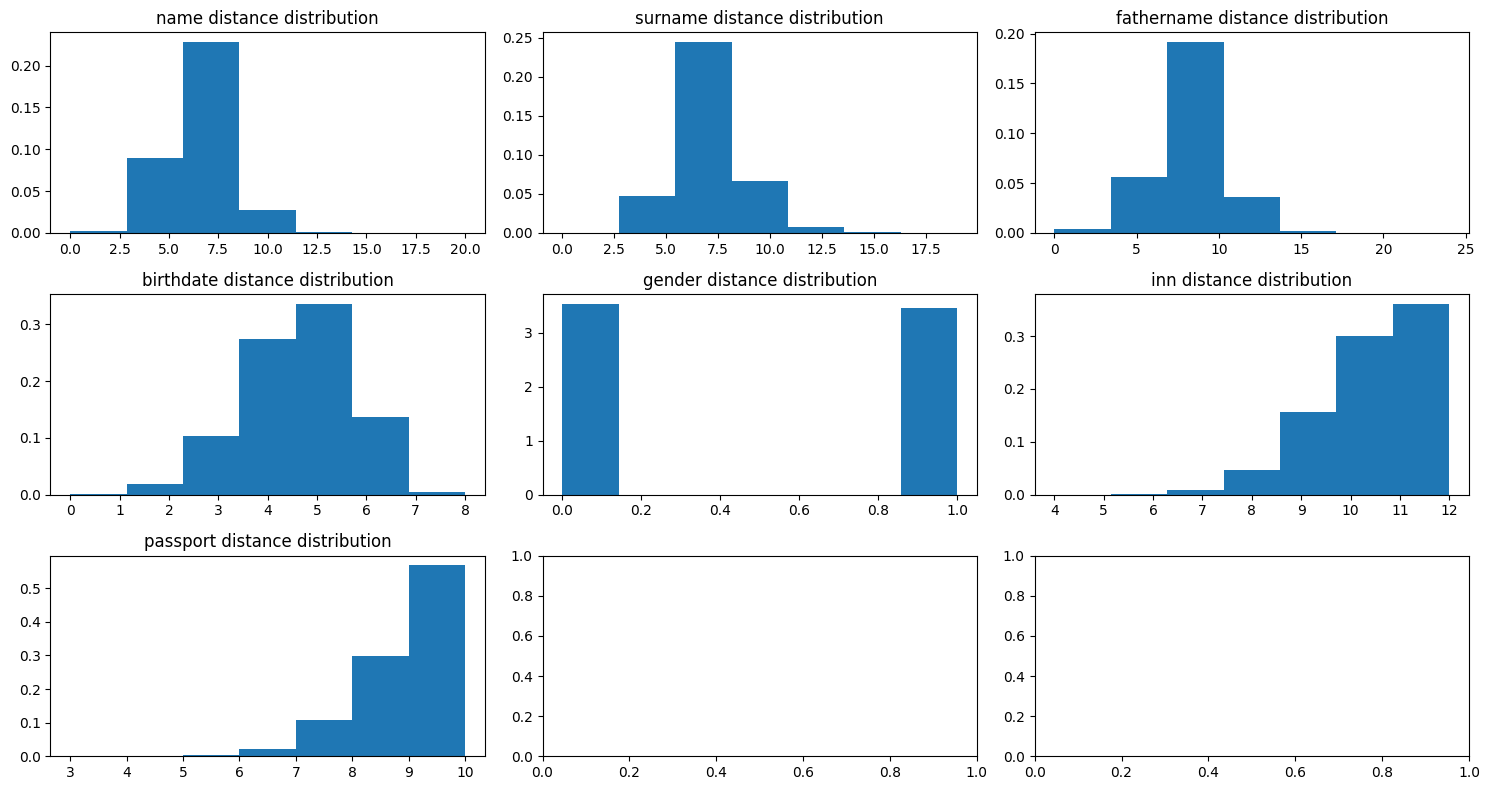

In [8]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))
ax = ax.flatten()
for i, (col, similarities) in enumerate(col_similarities.items()):
    
    ax[i].hist(similarities, bins=7, density=True)
    ax[i].set_title(f"{col} distance distribution")
    
plt.tight_layout()
plt.show()

Пол - очень важное поле, но максимальная дистанция по нему - 1, так что будем давать ему особый вес

In [10]:
# Приведём NaN значения к строковому типу
orcs.fillna(value="<NONE>", inplace=True)
employees.fillna(value="<NONE>", inplace=True)

`PyNNDescent` не умеет работать со строками, так что закодируем данные в целые числа

In [11]:
max_lens = {}
for col in employees.columns:
    max_lens[col] = max(employees[col].str.len().max(), orcs[col].str.len().max())

def encode_df(df: pd.DataFrame, max_lens: Dict[str, int]) -> pd.DataFrame:
    encoded_data = []
    cols = df.columns
    new_cols = [f"{col}_{i}" for col in cols for i in range(max_lens[col] + 1)]
    for _, row in df.iterrows():
        encoded_row = []
        for col, item in row.items():
            encoded_item = [ord(char) for char in item]
            encoded_item += [-1] * (max_lens[col] - len(item) + 1)
            encoded_row.extend(encoded_item)
        encoded_data.append(encoded_row)
    encoded_data = np.array(encoded_data, dtype=np.int32)
    
    encoded_df = pd.DataFrame(encoded_data, columns=new_cols)
    return encoded_df

def decode_df(encoded_df: pd.DataFrame) -> pd.DataFrame:
    decoded_data = []

    for _, row in encoded_df.iterrows():
        decoded_row = []
        for item in row:
            decoded_item = ''.join([chr(num) for num in item if num != -1])
            decoded_row.append(decoded_item)
        decoded_data.append(decoded_row)

    decoded_df = pd.DataFrame(decoded_data, columns=encoded_df.columns)
    return decoded_df



In [12]:
orcs_encoded = encode_df(orcs, max_lens)
employees_encoded = encode_df(employees, max_lens)

Ниже представлены `numba`-функции для подсчета расстояний для индекса. Пайплайн в общих чертах:

1. Каждая запись - 7 слов, для каждого слова считаем расстояние левенштейна с помощью `levenshtein_distance_arrays`
2. Если одна из строк - `<NONE>`, к расстоянию прибавляем дефолтное значение `2.5`
3. Отдельные расстояния складываем с весами, подобранными эмпирически:
    - 5.0 для пола
    - 0.5 для пасспорта и ИНН
    - 1.0 для остальных полей

In [2]:

@numba.njit()
def is_none(x: np.ndarray) -> bool:
    return x[0] == ord("<") and x[-1] == ord(">")


@numba.njit()
def levenshtein_distance_arrays(x: np.ndarray, y: np.ndarray) -> float:
    n = len(x)
    m = len(y)
    dp = np.zeros((n + 1, m + 1), dtype=np.float32)
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = min(dp[i - 1][j], dp[i][j - 1], dp[i - 1][j - 1]) + 1
    return dp[n][m]


@numba.njit()
def levenshtein_distance_entries(x: np.ndarray, y: np.ndarray) -> float:
    result = 0
    weights = [1.0, 1.0, 1.0, 5.0, 1.0, 0.5, 0.5]
    cur_weight_idx = 0

    x_left = 0
    y_left = 0
    x_right = 0
    y_right = 0

    while x_right < len(x) and y_right < len(y):
        if x[x_right] != -1:
            x_right += 1
        if y[y_right] != -1:
            y_right += 1

        if x[x_right] == -1 and y[y_right] == -1:
            x_subarray = x[x_left:x_right]
            y_subarray = y[y_left:y_right]
            if is_none(x_subarray) or is_none(y_subarray):
                result += 2.5
            else:
                result += weights[cur_weight_idx] * levenshtein_distance_arrays(
                    x_subarray, y_subarray
                )
            cur_weight_idx += 1
            while x_right < len(x) and x[x_right] == -1:
                x_right += 1
            while y_right < len(y) and y[y_right] == -1:
                y_right += 1
            x_left = x_right
            y_left = y_right
    return result

Создаём `PyNNDescent`-индекс. Гиперпараметры заданы так, чтобы он работал достаточно быстро

In [14]:
index = pynndescent.NNDescent(
    employees_encoded.values,
    metric=levenshtein_distance_entries,
    verbose=True,
    n_jobs=-1,
    n_neighbors=10,
    pruning_degree_multiplier=1.0,
    diversify_prob=1.0,
)
index.prepare()

Fri Dec 13 05:56:09 2024 Building RP forest with 32 trees
Fri Dec 13 05:56:49 2024 NN descent for 20 iterations
	 1  /  20
	 2  /  20
	 3  /  20
	 4  /  20
	 5  /  20
	 6  /  20
	 7  /  20
	 8  /  20
	 9  /  20
	 10  /  20
	 11  /  20
	 12  /  20
	 13  /  20
	 14  /  20
	 15  /  20
	 16  /  20
	 17  /  20
	 18  /  20
	 19  /  20
	 20  /  20
Fri Dec 13 06:09:34 2024 Worst tree score: 0.13225185
Fri Dec 13 06:09:34 2024 Mean tree score: 0.13543807
Fri Dec 13 06:09:34 2024 Best tree score: 0.13848061
Fri Dec 13 06:10:16 2024 Forward diversification reduced edges from 10117590 to 5423023
Fri Dec 13 06:10:37 2024 Reverse diversification reduced edges from 5423023 to 5423023
Fri Dec 13 06:10:42 2024 Degree pruning reduced edges from 6378576 to 5635208
Fri Dec 13 06:10:42 2024 Resorting data and graph based on tree order
Fri Dec 13 06:10:44 2024 Building and compiling search function


Индекс построен, делаем запрос по всем оркам, задаем `epsilon=0.2`, чтобы получить как можно более точные результаты

In [19]:
result_ids, result_dist = index.query(orcs_encoded.values, k=5, epsilon=0.2)

Результаты получены, но мы не знаем оптимальный порог для расстояния, так что сохраняем предсказания для разных порогов и сабмитим все на `Kaggle`

In [32]:
dfs = []
thresholds = [5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 10.5]
for threshold in thresholds:
    orc_ids = np.where(result_dist[:, 0] < threshold)[0]
    employee_ids = result_ids[orc_ids, 0]
    df = pd.DataFrame({"orc_ids": orc_ids, "employee_ids": employee_ids})
    dfs.append(df)

In [69]:
for df, thres in zip(dfs, thresholds):
    new_df = (
        pd.DataFrame(df["employee_ids"])
        .rename(columns={"employee_ids": "orig_index"})
        .reset_index(names="id")
    )
    new_df.to_parquet(f"submission@{thres}.parquet", index=False)